In [1]:
from schnetpack.md.utils import HDF5Loader
import json
import time
import numpy as np
import matplotlib.pyplot as plt
from schnetpack.md.utils import MDUnits

%load_ext autoreload
%autoreload 2

In [5]:
data = HDF5Loader('simulation_gpu_dipole_test_new_lvl4_all.hdf5', load_properties=True, skip_initial=500000)

Shape: (1499998, 1)


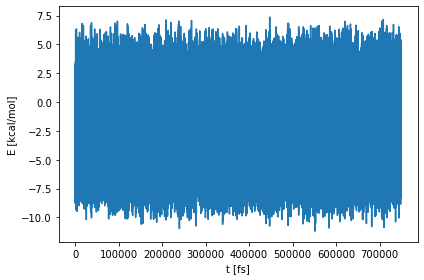

In [6]:
energies = data.get_property('energy')
print('Shape:', energies.shape)

# Get the time axis
time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

# Plot the energies
plt.figure()
plt.plot(time_axis, energies)
plt.ylabel('E [kcal/mol]')
plt.xlabel('t [fs]')
plt.tight_layout()
plt.show()

/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/ipykernel_launcher.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


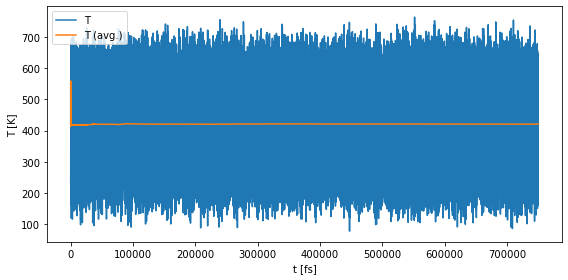

In [7]:
def plot_temperature(data):

    # Read the temperature
    temperature = data.get_temperature()

    # Compute the cumulative mean
    temperature_mean = np.cumsum(temperature) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, temperature, label='T')
    plt.plot(time_axis, temperature_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_temperature(data)

/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/ipykernel_launcher.py:18: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
/home/mihail/anaconda3/envs/equiv_dens/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


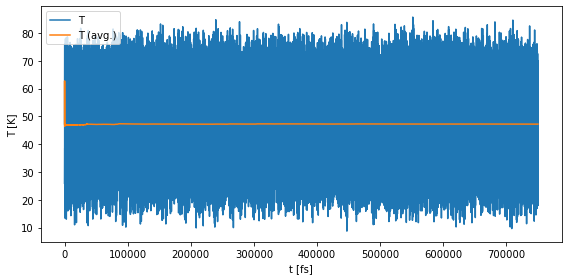

In [8]:
def plot_k_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy()

    # Compute the cumulative mean
    k_energy_mean = np.cumsum(k_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, k_energy, label='T')
    plt.plot(time_axis, k_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_k_energy(data)

std potential 2.404527
std kinetic 2.38509692780769
energy_unit 0.010364269574711572
kcal 2.5196637345688e+24
kJ 6.022140857000001e+23
ha 2625.4996387552483


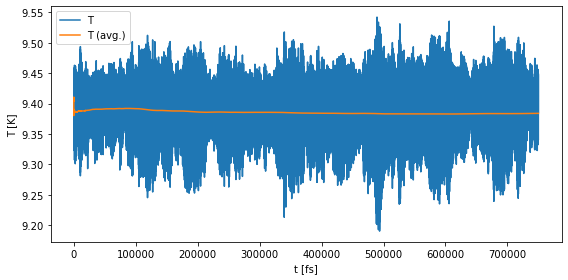

In [9]:
def plot_total_energy(data):

    # Read the k_energy
    k_energy = data.get_kinetic_energy() *  MDUnits.conversions['kj']/MDUnits.conversions['kcal']
    p_energy = data.get_property('energy').squeeze()
    print('std potential', np.std(p_energy))
    print('std kinetic', np.std(k_energy))
    print('energy_unit', MDUnits.energy_unit)
    print('kcal', MDUnits.conversions['kcal'])
    print('kJ', MDUnits.conversions['kj'])
    print('ha', MDUnits.conversions['ha'])
    total_energy = k_energy + p_energy

    # Compute the cumulative mean
    total_energy_mean = np.cumsum(total_energy) / (np.arange(data.entries)+1)

    # Get the time axis
    time_axis = np.arange(data.entries)*data.time_step / MDUnits.fs2internal # in fs

    plt.figure(figsize=(8,4))
    plt.plot(time_axis, total_energy, label='T')
    plt.plot(time_axis, total_energy_mean, label='T (avg.)')
    plt.ylabel('T [K]')
    plt.xlabel('t [fs]')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_total_energy(data)

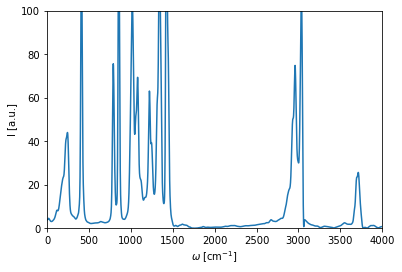

In [10]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=2)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



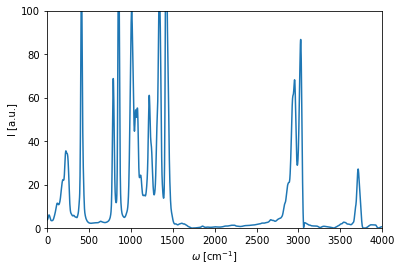

In [11]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.show()



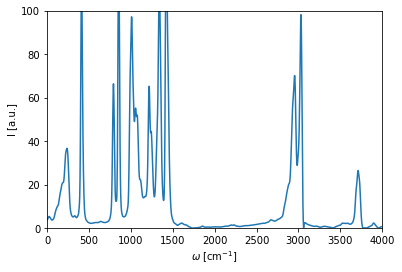

In [12]:
from schnetpack.md.utils.spectra import PowerSpectrum

spectrum = PowerSpectrum(data, resolution=4096)

spectrum.compute_spectrum(molecule_idx=3)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')


#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_vib_spectrum.svg')
plt.show()

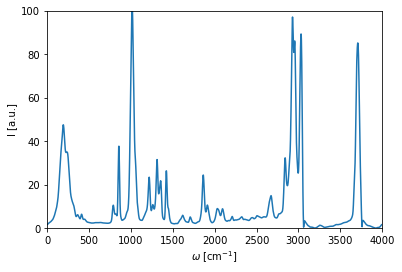

In [13]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=2)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
#plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_IR_spectrum.svg')
plt.show()

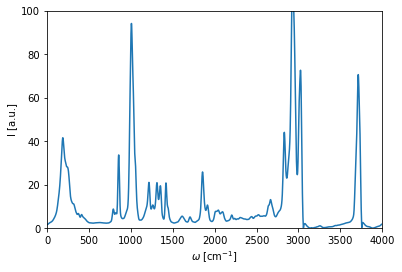

In [43]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=0)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_IR_spectrum_2.svg')
plt.show()


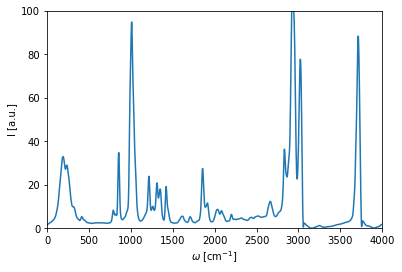

In [42]:
from schnetpack.md.utils.spectra import IRSpectrum

spectrum = IRSpectrum(data, dipole_moment_handle='dipole_moment', resolution=4096)

spectrum.compute_spectrum(molecule_idx=3)
freqencies, intensities = spectrum.get_spectrum()

# Plot the spectrum
plt.figure()
plt.plot(freqencies, intensities)
plt.xlim(0,4000)
plt.ylim(0,100)
plt.ylabel('I [a.u.]')
plt.xlabel('$\omega$ [cm$^{-1}$]')
plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/ml_ethanol_IR_spectrum_3.svg')
plt.show()


In [44]:
from schnetpack.md.utils.spectra import fft_autocorrelation
dpm = data.get_property('dipole_moment')
print(dpm.shape)
autocorr = np.zeros((3, dpm.shape[0] - 1))
for i in range(dpm.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(dpm[:, i], dpm.shape[0] - 2)

print(autocorr.shape)

(1999998, 3)
i 0
i 1
i 2
(3, 1999997)


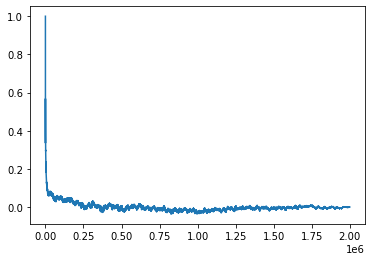

In [45]:
import matplotlib.pyplot as plt

plt.plot(np.mean(autocorr, axis=0))

plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/autocorrelation.svg')
plt.show()

[[ -9.441614   17.461538   10.003567 ]
 [-14.197825   17.806768    7.012605 ]
 [-16.37709    16.80541     3.2517908]
 ...
 [  4.3972135  -4.3956637 -14.314174 ]
 [  1.610875    1.8996595  -3.5803316]
 [  0.282228    9.897291    7.8966613]]
i 0
i 1
i 2
(3, 1999996)


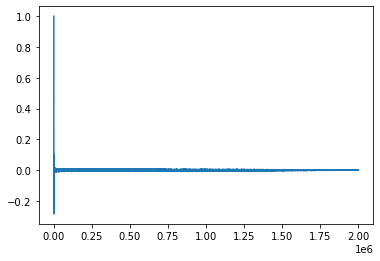

In [46]:
h = 0.5 / 1000

diff = np.diff(dpm, axis=0)
diff = diff/h
print(diff)

autocorr = np.zeros((3, diff.shape[0] - 1))
for i in range(diff.shape[1]):
    print('i', i)
    autocorr[i] = fft_autocorrelation(diff[:, i], diff.shape[0] - 2)
    
print(autocorr.shape)
plt.plot(np.mean(autocorr, axis=0))

plt.savefig('/home/mihail/Documents/Uni/PhD/equiv_dens/figures/diff_autocorrelation.svg')
plt.show()